In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

import simulate_data as sim
reload(sim)

import elbo
reload(elbo)

In [ ]:
rng= np.random.default_rng(42)

n, d = 1_000, 400
l_perc, u_perc = 10, 80
beta_scale = 4
perc_sig = 0.1

X = sim.X_corr_blocks(n, d, k = 20, corr =0.9, seed = 42)
beta_true = sim.beta_sparse(d+1, beta_scale, perc_sig, seed = 42)
y, l ,u = sim.y_tobit(X, l_perc, u_perc, beta_true, seed=42)

mask_l   = (y == l)
mask_u   = (y == u)
mask_mid = ~mask_l & ~mask_u

print("True beta:\n", beta_true)
print(f"Censored low: {mask_l.sum()}  |  uncensored: {mask_mid.sum()}  |  Censored high: {mask_u.sum()}")

plt.scatter(X[:,5], y)
plt.show()

In [4]:
tau2 = 10.0

# initialise near zero
m0        = np.zeros(d+1)
log_s0    = np.full(d+1, np.log(1.0))
log_sig0  = np.log(1.0)

print("\nRunning Adam optimisation …")
m_opt, log_s_opt, log_sig_opt, elbo_hist = elbo.adam(X, y,l,u, tau2,m0, log_s0, log_sig0,
                                                  lr=0.02, n_iter=2000)

s_opt       = np.exp(log_s_opt)
sigma2_opt  = np.exp(log_sig_opt)
print(f"\nEstimated σ_y = {np.sqrt(sigma2_opt):.4f}  (true = 1.0)")


Running Adam optimisation …
  iter  100  ELBO = -20822.6349
  iter  200  ELBO = -10263.3986
  iter  300  ELBO = -6982.1036
  iter  400  ELBO = -5502.1470
  iter  500  ELBO = -4702.7216
  iter  600  ELBO = -4221.8186
  iter  700  ELBO = -3911.0897
  iter  800  ELBO = -3699.8559
  iter  900  ELBO = -3550.7141
  iter 1000  ELBO = -3442.2721
  iter 1100  ELBO = -3361.5391
  iter 1200  ELBO = -3300.2411
  iter 1300  ELBO = -3252.9005
  iter 1400  ELBO = -3215.7720
  iter 1500  ELBO = -3186.2253
  iter 1600  ELBO = -3162.3702
  iter 1700  ELBO = -3142.8216
  iter 1800  ELBO = -3126.5475
  iter 1900  ELBO = -3112.7682
  iter 2000  ELBO = -3100.8872

Estimated σ_y = 4.9022  (true = 1.0)


In [5]:
print("\nRunning Adam optimisation …")
m_opt, log_s_opt, log_sig_opt, elbo_hist2 = elbo.adam(X, y,l,u, tau2,m_opt, log_s_opt, log_sig_opt,
                                                  lr=0.02, n_iter=2000)
elbo_hist = elbo_hist + elbo_hist2
s_opt       = np.exp(log_s_opt)
sigma2_opt  = np.exp(log_sig_opt)
print(f"\nEstimated σ_y = {np.sqrt(sigma2_opt):.4f}  (true = 1.0)")


Running Adam optimisation …
  iter  100  ELBO = -2823.4750
  iter  200  ELBO = -2636.5594
  iter  300  ELBO = -2612.2503
  iter  400  ELBO = -2607.8623
  iter  500  ELBO = -2607.8761
Early stopping

Estimated σ_y = 1.0073  (true = 1.0)


Text(0.5, 1.01, 'Variational Inference for Censored Regression')

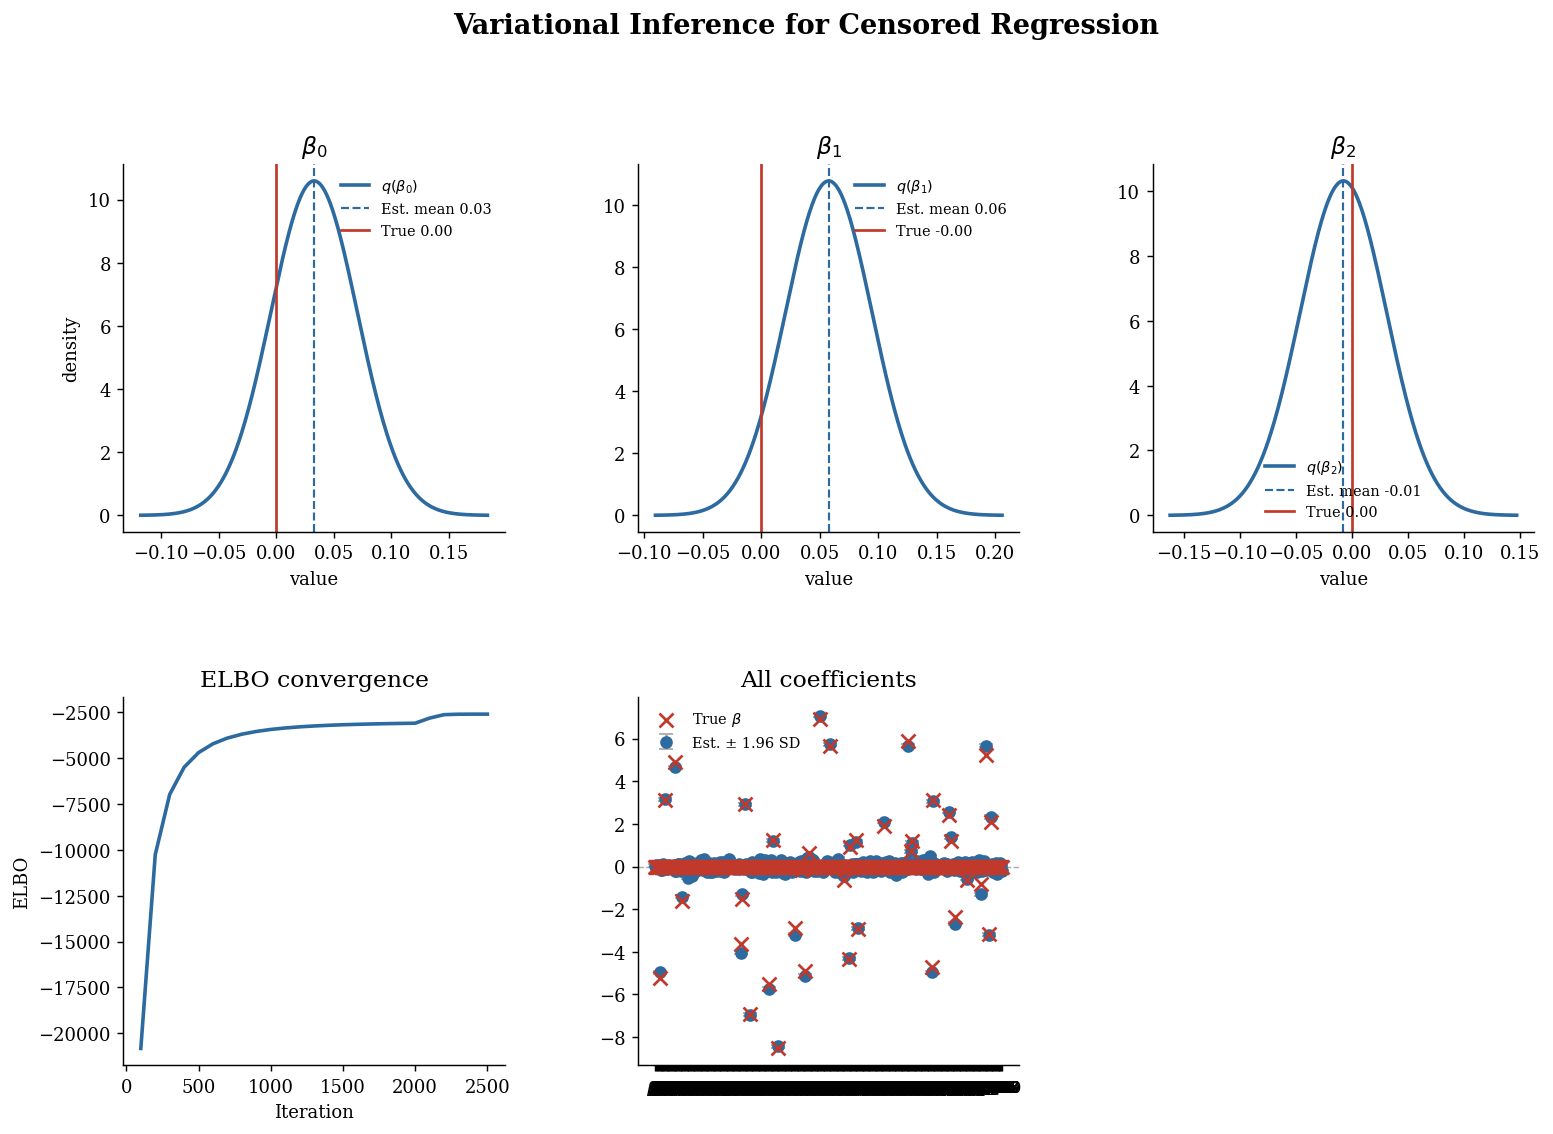

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.special import ndtr  # stable Phi
from numpy.polynomial.hermite import hermgauss
# ══════════════════════════════════════════════════════════════════════════════
# 5. Plots
# ══════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

BLUE   = "#2D6A9F"
RED    = "#C0392B"
GREY   = "#AAAAAA"

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── top row: marginal posteriors for β_0, β_1, β_2 ──────────────────────────
for j in range(3):
    ax = fig.add_subplot(gs[0, j])
    mu_j = m_opt[j]
    sd_j = np.sqrt(s_opt[j])
    z    = np.linspace(mu_j - 4*sd_j, mu_j + 4*sd_j, 400)
    ax.plot(z, norm.pdf(z, mu_j, sd_j), color=BLUE, lw=2, label="$q(\\beta_{%d})$" % j)
    ax.axvline(mu_j,          color=BLUE, lw=1.2, ls="--", label=f"Est. mean {mu_j:.2f}")
    ax.axvline(beta_true[j],  color=RED,  lw=1.5, ls="-",  label=f"True {beta_true[j]:.2f}")
    ax.set_title(f"$\\beta_{j}$", fontsize=13)
    ax.set_xlabel("value", fontsize=10)
    ax.set_ylabel("density" if j == 0 else "", fontsize=10)
    ax.legend(fontsize=8, frameon=False)

# ── bottom-left: ELBO convergence ───────────────────────────────────────────
ax_elbo = fig.add_subplot(gs[1, 0])
iters   = np.arange(100, 100 * len(elbo_hist) + 1, 100)
ax_elbo.plot(iters, elbo_hist, color=BLUE, lw=2)
ax_elbo.set_xlabel("Iteration", fontsize=10)
ax_elbo.set_ylabel("ELBO", fontsize=10)
ax_elbo.set_title("ELBO convergence", fontsize=13)

# ── bottom-middle: true vs estimated β ──────────────────────────────────────
ax_beta = fig.add_subplot(gs[1, 1])
idx = np.arange(d+1)
ax_beta.errorbar(idx, m_opt,
                 yerr=1.96 * np.sqrt(s_opt),
                 fmt='o', color=BLUE, ecolor=GREY, capsize=4,
                 label="Est. ± 1.96 SD")
ax_beta.scatter(idx, beta_true, color=RED, zorder=5, marker='x', s=60,
                label="True $\\beta$")
ax_beta.axhline(0, color=GREY, lw=0.8, ls="--")
ax_beta.set_xticks(idx)
ax_beta.set_xticklabels([f"$\\beta_{j}$" for j in idx], fontsize=9)
ax_beta.set_title("All coefficients", fontsize=13)
ax_beta.legend(fontsize=8, frameon=False)


fig.suptitle("Variational Inference for Censored Regression",
             fontsize=15, fontweight="bold", y=1.01)

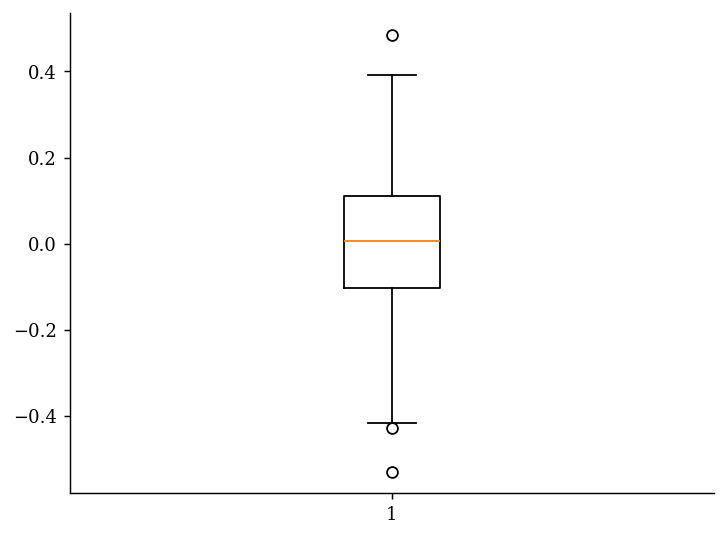

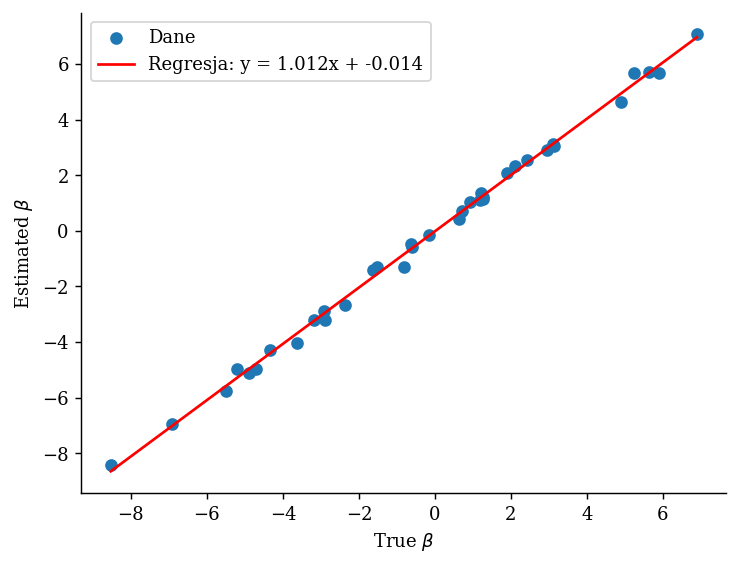

In [7]:
beta_zero = beta_true == 0

plt.boxplot(m_opt[beta_zero])
plt.show()

y1 = m_opt[~beta_zero]
x1 = beta_true[~beta_zero]


plt.scatter(x1, y1, label='Dane')
plt.xlabel("True $\\beta$")
plt.ylabel("Estimated $\\beta$")

a, b = np.polyfit(x1, y1, 1)
x_line = np.linspace(np.min(x1), np.max(x1), 100)
y_line = a * x_line + b

plt.plot(x_line, y_line, color='red', label=f'Regresja: y = {a:.3f}x + {b:.3f}')

plt.legend()

plt.show()

In [8]:
import pandas as pd

k = 2
df = pd.DataFrame()
df['beta_true'] = beta_true
df['beta_est'] = m_opt
df['s_est'] = s_opt
df['est_zero'] = df.beta_est.abs() < (k * 1.96 * np.sqrt(df.s_est))

import numpy as np
import pandas as pd

# Zakładam, że masz w pamięci swój DataFrame 'df' oraz macierz eksperymentu 'X'

# 1. Pobieramy numery indeksów prawdziwych, niezerowych parametrów
true_nonzero_indices = np.where(df['beta_true'] != 0)[0]

if len(true_nonzero_indices) > 0:

    all_indices = np.arange(len(df))

    diff_matrix = np.abs(all_indices[:, np.newaxis] - true_nonzero_indices)

    closest_idx_in_array = np.argmin(diff_matrix, axis=1)
    closest_row_indices = true_nonzero_indices[closest_idx_in_array]

    df['true_nonzero_beta_index'] = closest_row_indices

    correlations = []
    for i, target_i in zip(all_indices, closest_row_indices):
        corr = np.corrcoef(X[:, i], X[:, target_i])[0, 1]
        correlations.append(corr)

    df['corr_X'] = correlations

else:
    df['true_nonzero_beta_index'] = np.nan
    df['corr_X'] = np.nan

display(df.head())

# FPR = FP / (FP + TN)
fpr = ((df.beta_true == 0) & (~df.est_zero)).sum() / (~df.est_zero).sum()

# TPR = TP / (TP + FN)
tpr = ((df.beta_true != 0) & (~df.est_zero)).sum() / (df.beta_true != 0).sum()

print("Percent of false positives (FPR):", fpr)
print("Percent of true positives (TPR):", tpr)

display(df[~df.est_zero].head())

/mnt/nfs/clustersw/Debian/bookworm/jupyterhub/1.0/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/nfs/clustersw/Debian/bookworm/jupyterhub/1.0/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,beta_true,beta_est,s_est,est_zero,true_nonzero_beta_index,corr_X
0,0.0,0.032993,0.001419,True,5,NaN
1,-0.0,0.057616,0.001370,True,5,0.894939
2,0.0,-0.007605,0.001496,True,5,0.894942
3,0.0,0.032548,0.001489,True,5,0.886676
4,-0.0,0.049709,0.001493,True,5,0.890093


Percent of false positives (FPR): 0.7852760736196319
Percent of true positives (TPR): 0.9722222222222222


,beta_true,beta_est,s_est,est_zero,true_nonzero_beta_index,corr_X
5,-5.208718,-4.962234,0.001463,False,5,1.000000
11,3.111168,3.142503,0.001467,False,11,1.000000
22,4.890165,4.642254,0.001539,False,22,1.000000
23,-0.000000,-0.191160,0.001527,False,22,0.903564
24,-0.000000,-0.188218,0.001546,False,22,0.900034


In [9]:
df[~df.est_zero].head()

,beta_true,beta_est,s_est,est_zero,true_nonzero_beta_index,corr_X
5,-5.208718,-4.962234,0.001463,False,5,1.000000
11,3.111168,3.142503,0.001467,False,11,1.000000
22,4.890165,4.642254,0.001539,False,22,1.000000
23,-0.000000,-0.191160,0.001527,False,22,0.903564
24,-0.000000,-0.188218,0.001546,False,22,0.900034
